# 6 – Multimodal Health RAG with CLIP

**⚠️  DISCLAIMER: This is an EDUCATIONAL DEMO ONLY. Not for medical diagnosis or advice.**

**Learning Goals:**
- Embed images and text using CLIP
- Build multimodal retrieval (text→image, image→image, text+image fusion)
- Use score fusion (weighted average, RRF)
- Visualize multimodal search results

**What we'll build:**
1. Load health dataset (images + metadata)
2. Embed images with CLIP visual encoder
3. Embed text with CLIP text encoder (or separate SBERT)
4. Store in separate ChromaDB collections
5. Query modes: text-only, image-only, fused
6. RAG with image context

**Persistence:**
- `./artifacts/chroma/health_text/`
- `./artifacts/chroma/health_image/`
- `./artifacts/manifests/health.json`


![Sample Image](https://private-us-east-1.manuscdn.com/sessionFile/nD2H1mYlwtgxyECVDyboot/sandbox/DYurrAWMRAC8roWSr0vk9A_1770256694543_na1fn_L2hvbWUvdWJ1bnR1L2VtYmVkZGluZ19zcGFjZV9zaW1wbGU.png?Policy=eyJTdGF0ZW1lbnQiOlt7IlJlc291cmNlIjoiaHR0cHM6Ly9wcml2YXRlLXVzLWVhc3QtMS5tYW51c2Nkbi5jb20vc2Vzc2lvbkZpbGUvbkQySDFtWWx3dGd4eUVDVkR5Ym9vdC9zYW5kYm94L0RZdXJyQVdNUkFDOHJvV1NyMHZrOUFfMTc3MDI1NjY5NDU0M19uYTFmbl9MMmh2YldVdmRXSjFiblIxTDJWdFltVmtaR2x1WjE5emNHRmpaVjl6YVcxd2JHVS5wbmciLCJDb25kaXRpb24iOnsiRGF0ZUxlc3NUaGFuIjp7IkFXUzpFcG9jaFRpbWUiOjE3OTg3NjE2MDB9fX1dfQ__&Key-Pair-Id=K2HSFNDJXOU9YS&Signature=YuqUWyT6el-Ke-o~6TiUwyjKTKSd86K9mL9vdTxtZKUFCURH8~T9FK5d9TZ8tVMd7R-UJdtkWVscfUCLcj2B7mQYhE4Hr~b~5X-ZbpMkQnZ64rFAAwEDQWIbnxfzmYVd88Qv8ucSNLpbNda0mn4xjNvtVj0-G~aBaioVbYHd8mckcgrYLvC4LgorV2QcN~NZOKbqTpWWwLm95vIGhe0EWwyVauw7BOUgNaDGKeUhisNem-S~D23k41oHb34ZSjZKLHeGsNkPKofaFxdkijoMGlm1M0S8tIJRiPi8kFvFLG1g9uHj9ze0nOLEeDYwKl3Bhq6URY-10ep8-V4DY5KleA__)

In [13]:
# ⚙️ Global Config & Services (using centralized modules)

import json
import sys
from pathlib import Path
from datetime import datetime
from dotenv import load_dotenv

# Add parent directory to path and change to project root
import os

# Get the current directory and navigate to project root
current_dir = Path.cwd()
if current_dir.name == "homework":
    project_root = current_dir.parent
elif current_dir.name == "notebooks":
    project_root = current_dir.parent
else:
    project_root = current_dir

# Change to project root and add to path
os.chdir(project_root)
sys.path.insert(0, str(project_root))

print(f"📂 Working directory: {os.getcwd()}")

from src.services.llm_services import (
    load_config,
    get_llm,
    get_clip_model,
    get_text_embeddings,
    validate_api_keys,
    print_config_summary
)

# Load environment variables
load_dotenv()

# Load configuration from config.yaml (now we're in project root)
config = load_config("src/config/config.yaml")

# Validate API keys
validate_api_keys(config, verbose=True)

# Print summary
print("⚠️  EDUCATIONAL DEMO ONLY - NOT FOR MEDICAL DIAGNOSIS\n")
print_config_summary(config)
print(f"  CLIP: {config['clip_model']}")
print(f"  Subset size: {config['subset_n']}")


📂 Working directory: /Users/machinelearningzuu/Dropbox/Zuu Crew/Courses/🚧 AI Engineer Essentials/Live Classes/Week 03
⚠️  EDUCATIONAL DEMO ONLY - NOT FOR MEDICAL DIAGNOSIS

✅ Config loaded:
  LLM: openrouter (openai/gpt-4o-mini)
  Embeddings: sbert / sentence-transformers/all-MiniLM-L6-v2
  Temperature: 0.2
  Artifacts: ./artifacts
  CLIP: clip-ViT-B-32
  Subset size: 50


/Users/machinelearningzuu/Dropbox/Zuu Crew/Courses/🚧 AI Engineer Essentials/Live Classes/Week 03/src/services/llm_services.py:375: UserWarning: ⚠️  GROQ_API_KEY not found in environment
  warnings.warn(f"⚠️  {key} not found in environment")
/Users/machinelearningzuu/Dropbox/Zuu Crew/Courses/🚧 AI Engineer Essentials/Live Classes/Week 03/src/services/llm_services.py:375: UserWarning: ⚠️  GOOGLE_API_KEY not found in environment
  warnings.warn(f"⚠️  {key} not found in environment")
/Users/machinelearningzuu/Dropbox/Zuu Crew/Courses/🚧 AI Engineer Essentials/Live Classes/Week 03/src/services/llm_services.py:375: UserWarning: ⚠️  COHERE_API_KEY not found in environment
  warnings.warn(f"⚠️  {key} not found in environment")


In [14]:
# Initialize LLM, CLIP, and Text Embeddings using factories from llm_services
llm = get_llm(config)
clip_model = get_clip_model(config)
text_embeddings = get_text_embeddings(config)

print(f"✅ LLM: {config['llm_provider']} / {config.get('openrouter_model', config.get('llm_model'))}")
print(f"✅ CLIP: {config['clip_model']}")
print(f"✅ Text embeddings: {'CLIP' if config.get('text_in_clip_space') else config['text_emb_model']}")

# Verify API key with test completion
print("\n🔍 Testing LLM API connection...")
try:
    test_response = llm.invoke("Say 'API working!' if you can read this.")
    test_msg = test_response.content if hasattr(test_response, 'content') else str(test_response)
    print(f"✅ LLM API verified: {test_msg[:50]}")
except Exception as e:
    print(f"❌ LLM API test failed: {e}")
    print("⚠️  Please check your .env file and API key configuration.")


✅ LLM: openrouter / gpt-4o-mini
✅ CLIP: clip-ViT-B-32
✅ Text embeddings: sentence-transformers/all-MiniLM-L6-v2

🔍 Testing LLM API connection...
✅ LLM API verified: API working!


---

## Step 1: Load DermaMNIST Dataset

We'll use **DermaMNIST** - a standardized dataset of 10,000 dermatoscopic images from HAM10000.

**Dataset:** 7 skin disease categories with labeled images (128×128 RGB)  
**Source:** https://zenodo.org/records/10519652


In [4]:
import pandas as pd
import numpy as np
from PIL import Image

images_dir = Path(config["data_root"]) / "images"
images_dir.mkdir(parents=True, exist_ok=True)

# Load DermaMNIST dataset (.npz file with real dermatology images)
dermamnist_path = images_dir / "dermamnist_128.npz"

# Disease category mappings (7 categories in DermaMNIST from HAM10000)
label_names = {
    0: "Actinic Keratoses",
    1: "Basal Cell Carcinoma",
    2: "Benign Keratosis",
    3: "Dermatofibroma",
    4: "Melanoma",
    5: "Melanocytic Nevi",
    6: "Vascular Lesions"
}

label_descriptions = {
    0: "Pre-cancerous skin lesions caused by long-term UV exposure. Appear as rough, scaly patches on sun-exposed areas. Treatment includes cryotherapy or topical medications.",
    1: "Most common type of skin cancer, rarely spreads. Appears as pearly or waxy bumps, flat scaly patches. Treatment: surgical excision with high cure rate.",
    2: "Non-cancerous skin growths (seborrheic keratoses). Brown, black or tan warty spots. Generally harmless, treatment for cosmetic reasons if desired.",
    3: "Benign fibrous tumor under the skin, feels like a hard bump. Common on legs. Treatment: observation or surgical removal if symptomatic.",
    4: "Most serious form of skin cancer, can metastasize. ABCDE warning signs: Asymmetry, Border, Color, Diameter, Evolving. Treatment: urgent surgical excision.",
    5: "Common benign moles (melanocytic tumors). Most people have 10-40. Monitor for changes. Treatment: removal if suspicious or concerning.",
    6: "Benign blood vessel growths (hemangiomas, angiomas). Red or purple discoloration. Treatment: laser therapy, observation, or sclerotherapy."
}

if dermamnist_path.exists():
    print("🏥 Loading DermaMNIST dataset (real dermatology images from HAM10000)...")
    
    # Load .npz file
    data = np.load(dermamnist_path)
    
    # Use training set, limit to subset_n
    n_samples = min(config["subset_n"], len(data['train_images']))
    images_array = data['train_images'][:n_samples]  # Shape: (N, 128, 128, 3), dtype: uint8
    labels_array = data['train_labels'][:n_samples].flatten()  # Shape: (N,), values: 0-6
    
    print(f"  Dataset info:")
    print(f"    Total available: {len(data['train_images'])} training images")
    print(f"    Using subset: {n_samples} images")
    print(f"    Image resolution: {images_array[0].shape[0]}×{images_array[0].shape[1]}")
    print(f"    Channels: {images_array[0].shape[2]} (RGB)")
    
    # Create metadata DataFrame and save images to disk
    items = []
    saved_dir = images_dir / "dermamnist"
    saved_dir.mkdir(exist_ok=True)
    
    for i, (img_array, label) in enumerate(zip(images_array, labels_array)):
        item_id = f"derma_{i:03d}"
        img_filename = f"{item_id}.png"
        img_path_full = saved_dir / img_filename
        
        # Convert numpy array to PIL Image and save
        img = Image.fromarray(img_array.astype('uint8'), 'RGB')
        img.save(img_path_full)
        
        items.append({
            "item_id": item_id,
            "title": label_names[label],
            "description": label_descriptions[label],
            "category": label_names[label].lower().replace(" ", "_"),
            "img_path": str(img_path_full.relative_to(config["data_root"])),
            "label": int(label)
        })
    
    df = pd.DataFrame(items)
    print(f"✅ Loaded {len(df)} real dermatology images")
    print(f"  Categories: {sorted(df['category'].unique())}")
    print(f"  Images extracted to: {saved_dir}")
    
else:
    print(f"❌ DermaMNIST dataset not found at: {dermamnist_path}")
    print("\n📥 Please download the dataset:")
    print("  URL: https://zenodo.org/records/10519652/files/dermamnist_128.npz")
    print(f"  Save to: {dermamnist_path}")
    raise FileNotFoundError(f"DermaMNIST dataset required. Download and place at: {dermamnist_path}")

print(f"\n📊 Dataset summary:")
print(df.head())
print(f"\n📈 Category distribution:\n{df['category'].value_counts()}")


🏥 Loading DermaMNIST dataset (real dermatology images from HAM10000)...
  Dataset info:
    Total available: 7007 training images
    Using subset: 50 images
    Image resolution: 128×128
    Channels: 3 (RGB)
✅ Loaded 50 real dermatology images
  Categories: ['actinic_keratoses', 'basal_cell_carcinoma', 'benign_keratosis', 'melanocytic_nevi', 'melanoma', 'vascular_lesions']
  Images extracted to: data/images/dermamnist

📊 Dataset summary:
     item_id              title  \
0  derma_000  Actinic Keratoses   
1  derma_001   Melanocytic Nevi   
2  derma_002   Melanocytic Nevi   
3  derma_003   Melanocytic Nevi   
4  derma_004           Melanoma   

                                         description           category  \
0  Pre-cancerous skin lesions caused by long-term...  actinic_keratoses   
1  Common benign moles (melanocytic tumors). Most...   melanocytic_nevi   
2  Common benign moles (melanocytic tumors). Most...   melanocytic_nevi   
3  Common benign moles (melanocytic tumors). 

---

## Step 2: Embed Images with CLIP

We'll encode all images using CLIP's vision tower.


In [15]:
from PIL import Image as PILImage

def encode_images(df, clip_model):
    """Encode images using CLIP."""
    image_embeddings = []
    valid_indices = []
    
    for idx, row in df.iterrows():
        img_path = Path(config["data_root"]) / row["img_path"]
        try:
            img = PILImage.open(img_path).convert("RGB")
            emb = clip_model.encode(img, convert_to_numpy=True)
            image_embeddings.append(emb)
            valid_indices.append(idx)
        except Exception as e:
            print(f"⚠️  Failed to load {img_path}: {e}")
    
    return np.array(image_embeddings), valid_indices

print("🖼️  Encoding images with CLIP...")
image_embeddings, valid_indices = encode_images(df, clip_model)

print(f"✅ Encoded {len(image_embeddings)} images")
print(f"  Embedding shape: {image_embeddings.shape}")


🖼️  Encoding images with CLIP...
✅ Encoded 50 images
  Embedding shape: (50, 512)


In [16]:
image_embeddings[0]

array([ 1.02622360e-01,  3.33196446e-02,  3.38661551e-01,  1.85268819e-01,
       -3.08098197e-01, -6.10434934e-02,  1.60262644e-01,  3.50511998e-01,
        5.33123970e-01, -4.41061556e-01,  1.35333955e-01, -1.73528686e-01,
       -1.18151814e-01,  4.66187119e-01, -1.65346816e-01, -2.26078123e-01,
        6.78981394e-02,  2.24432468e-01,  5.53592265e-01,  2.32477546e-01,
       -8.72742593e-01,  2.00160325e-01, -3.74612302e-01, -1.31374449e-01,
       -5.74525297e-02,  8.47973526e-02, -1.84294134e-01, -2.10104391e-01,
       -5.39242327e-01,  3.59562963e-01,  3.62881124e-01,  2.03912109e-01,
        1.05968565e-02, -8.40154886e-01, -3.57534796e-01,  5.23839742e-02,
       -2.16487706e-01, -1.96593583e-01, -3.25031757e-01, -5.27409434e-01,
       -1.02145553e-01,  8.03583488e-02, -5.64249873e-01, -3.28313589e-01,
        4.52288568e-01, -1.12223625e+00,  3.03068548e-01,  1.78317279e-01,
       -3.23389173e-02,  3.36378962e-02,  3.11401427e-01, -9.30956565e-03,
        6.08435631e-01,  

---

## Step 3: Build ChromaDB Collections

We'll create two collections:
1. **health_text**: Text descriptions (title + description)
2. **health_image**: Image embeddings


In [17]:
from langchain_core.documents import Document
from langchain_chroma import Chroma
import chromadb

chroma_root = Path(config["artifacts_root"]) / "chroma"

# Collection 1: Text embeddings
print("📝 Building text collection...")

text_docs = []
for idx, row in df.iterrows():
    text = f"{row['title']}. {row['description']}"
    metadata = {
        "item_id": row["item_id"],
        "title": row["title"],
        "category": row["category"],
        "img_path": row["img_path"],
    }
    text_docs.append(Document(page_content=text, metadata=metadata))

text_vectorstore = Chroma.from_documents(
    documents=text_docs,
    embedding=text_embeddings,
    collection_name="health_text",
    persist_directory=str(chroma_root / "health_text"),
)

print(f"✅ Text collection: {len(text_docs)} docs")

# Collection 2: Image embeddings (manual ChromaDB)
print("\n🖼️  Building image collection...")

chroma_client = chromadb.PersistentClient(path=str(chroma_root / "health_image"))
image_collection = chroma_client.get_or_create_collection("health_image")

# Add image embeddings
ids = [df.iloc[i]["item_id"] for i in valid_indices]
metadatas = [
    {
        "item_id": df.iloc[i]["item_id"],
        "title": df.iloc[i]["title"],
        "category": df.iloc[i]["category"],
        "img_path": df.iloc[i]["img_path"],
    }
    for i in valid_indices
]
embeddings_list = image_embeddings.tolist()

image_collection.add(
    ids=ids,
    embeddings=embeddings_list,
    metadatas=metadatas,
)

print(f"✅ Image collection: {len(ids)} images")
print(f"\n✅ Both collections built!")


📝 Building text collection...
✅ Text collection: 50 docs

🖼️  Building image collection...
✅ Image collection: 50 images

✅ Both collections built!


---

## Step 4: Query Modes

### Mode 1: Text-only retrieval


In [18]:
def text_only_search(query: str, top_k: int = 3, category_filter: str = None):
    """Search using text embeddings only."""
    retriever = text_vectorstore.as_retriever(search_kwargs={"k": top_k})
    
    # Apply filter if specified
    if category_filter:
        retriever.search_kwargs["filter"] = {"category": category_filter}
    
    results = retriever.invoke(query)
    return results

# Test
query = "eczema and inflammatory skin conditions"
results = text_only_search(query, top_k=3)

print(f"📝 Text-only search: '{query}'\\n")
for i, doc in enumerate(results, 1):
    print(f"[{i}] {doc.metadata['title']} ({doc.metadata['category']})")
    print(f"    {doc.page_content[:80]}...\\n")


📝 Text-only search: 'eczema and inflammatory skin conditions'\n
[1] Actinic Keratoses (actinic_keratoses)
    Actinic Keratoses. Pre-cancerous skin lesions caused by long-term UV exposure. A...\n
[2] Actinic Keratoses (actinic_keratoses)
    Actinic Keratoses. Pre-cancerous skin lesions caused by long-term UV exposure. A...\n
[3] Actinic Keratoses (actinic_keratoses)
    Actinic Keratoses. Pre-cancerous skin lesions caused by long-term UV exposure. A...\n


### Mode 2: Image-only retrieval


In [19]:
def image_search(query_text: str, top_k: int = 3):
    """Search images using CLIP text-to-image."""
    # Encode query text using CLIP
    query_emb = clip_model.encode(query_text, convert_to_numpy=True).tolist()
    
    # Query image collection
    results = image_collection.query(
        query_embeddings=[query_emb],
        n_results=top_k,
    )
    
    return results

# Test
query = "psoriasis and autoimmune skin disease"
results = image_search(query, top_k=3)

print(f"🖼️  Image search: '{query}'\\n")
for i, (item_id, metadata) in enumerate(zip(results['ids'][0], results['metadatas'][0]), 1):
    print(f"[{i}] {metadata['title']} ({metadata['category']})")
    print(f"    {item_id}\\n")


🖼️  Image search: 'psoriasis and autoimmune skin disease'\n
[1] Basal Cell Carcinoma (basal_cell_carcinoma)
    derma_033\n
[2] Melanocytic Nevi (melanocytic_nevi)
    derma_032\n
[3] Melanocytic Nevi (melanocytic_nevi)
    derma_038\n


### Mode 3: Fusion (Text + Image)

Combine text and image retrieval using score fusion.


In [20]:
def fused_search(query: str, top_k: int = 3, text_weight: float = 0.5):
    """Fuse text and image retrieval results."""
    # Text search
    text_results = text_only_search(query, top_k=top_k*2)
    text_scores = {doc.metadata['item_id']: 1.0 - i*0.1 for i, doc in enumerate(text_results)}
    
    # Image search
    img_results = image_search(query, top_k=top_k*2)
    img_scores = {}
    for i, (item_id, distance) in enumerate(zip(img_results['ids'][0], img_results['distances'][0])):
        # Convert distance to similarity score
        img_scores[item_id] = 1.0 / (1.0 + distance)
    
    # Normalize scores
    def normalize_scores(scores):
        vals = list(scores.values())
        min_val, max_val = min(vals), max(vals)
        if max_val == min_val:
            return {k: 1.0 for k in scores}
        return {k: (v - min_val) / (max_val - min_val) for k, v in scores.items()}
    
    text_scores = normalize_scores(text_scores)
    img_scores = normalize_scores(img_scores)
    
    # Weighted fusion
    fused_scores = {}
    all_ids = set(text_scores.keys()) | set(img_scores.keys())
    
    for item_id in all_ids:
        t_score = text_scores.get(item_id, 0.0)
        i_score = img_scores.get(item_id, 0.0)
        fused_scores[item_id] = text_weight * t_score + (1 - text_weight) * i_score
    
    # Sort and get top-k
    sorted_ids = sorted(fused_scores.items(), key=lambda x: x[1], reverse=True)[:top_k]
    
    return sorted_ids, text_scores, img_scores

# Test
query = "fungal skin infections"
fused, t_scores, i_scores = fused_search(query, top_k=3, text_weight=0.6)

print(f"🔀 Fused search (60% text, 40% image): '{query}'\\n")
for i, (item_id, score) in enumerate(fused, 1):
    row = df[df['item_id'] == item_id].iloc[0]
    t = t_scores.get(item_id, 0.0)
    im = i_scores.get(item_id, 0.0)
    print(f"[{i}] {row['title']} ({row['category']})")
    print(f"    Fused: {score:.3f} (text: {t:.3f}, image: {im:.3f})\\n")


🔀 Fused search (60% text, 40% image): 'fungal skin infections'\n
[1] Actinic Keratoses (actinic_keratoses)
    Fused: 0.600 (text: 1.000, image: 0.000)\n
[2] Basal Cell Carcinoma (basal_cell_carcinoma)
    Fused: 0.400 (text: 0.000, image: 1.000)\n
[3] Benign Keratosis (benign_keratosis)
    Fused: 0.300 (text: 0.500, image: 0.000)\n


---

## Step 5: Visualization

Display top-k images in a grid.


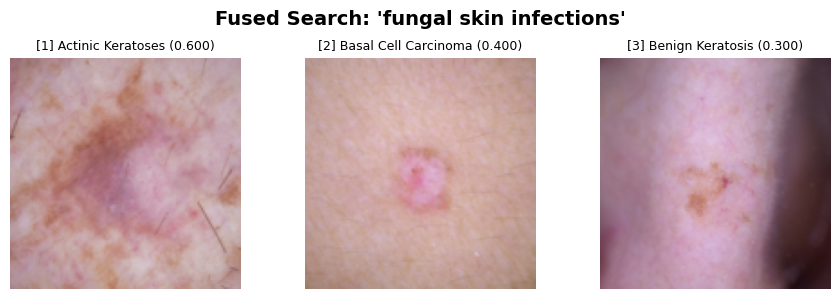

In [21]:
import matplotlib.pyplot as plt

def visualize_results(item_ids, scores=None, title="Search Results", ncols=3):
    """Display images in a grid."""
    nrows = (len(item_ids) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*3, nrows*3))
    
    # Handle axes array properly for different grid sizes
    if nrows == 1 and ncols == 1:
        axes = [axes]  # Single subplot
    elif nrows == 1 or ncols == 1:
        axes = axes if isinstance(axes, np.ndarray) else [axes]
    else:
        axes = axes.flatten()  # 2D grid
    
    for i, item_id in enumerate(item_ids):
        row = df[df['item_id'] == item_id].iloc[0]
        img_path = Path(config["data_root"]) / row["img_path"]
        img = PILImage.open(img_path)
        
        axes[i].imshow(img)
        axes[i].axis('off')
        
        score_str = f" ({scores[item_id]:.3f})" if scores else ""
        axes[i].set_title(f"[{i+1}] {row['title']}{score_str}", fontsize=9)
    
    # Hide unused subplots
    for i in range(len(item_ids), len(axes)):
        axes[i].axis('off')
    
    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Visualize fused results
visualize_results(
    [item_id for item_id, _ in fused],
    scores={item_id: score for item_id, score in fused},
    title=f"Fused Search: '{query}'"
)


---

## Step 6: RAG with Image Context

Use retrieved items as context for LLM generation.


In [22]:
from langchain_core.prompts import ChatPromptTemplate

def multimodal_rag(query: str, top_k: int = 3):
    """RAG using multimodal retrieval."""
    # Retrieve
    fused_results, _, _ = fused_search(query, top_k=top_k)
    
    # Build context
    context_parts = []
    for i, (item_id, score) in enumerate(fused_results, 1):
        row = df[df['item_id'] == item_id].iloc[0]
        context_parts.append(f"[{i}] {row['title']} ({row['category']}): {row['description']}")
    
    context = "\\n".join(context_parts)
    
    # RAG prompt
    prompt = ChatPromptTemplate.from_template(
        """You are an educational health assistant. Use ONLY the provided context to answer.
This is for EDUCATIONAL purposes only, NOT medical diagnosis or advice.

Context:
{context}

Question: {question}

Answer (keep under 6 sentences):"""
    )
    
    # Generate
    chain = prompt | llm
    response = chain.invoke({"context": context, "question": query})
    answer = response.content if hasattr(response, 'content') else str(response)
    
    return answer, fused_results

# Test
query = "Tell me about treatment options for skin conditions"
answer, results = multimodal_rag(query, top_k=3)

print(f"❓ Query: {query}\\n")
print(f"📚 Retrieved items:")
for i, (item_id, score) in enumerate(results, 1):
    row = df[df['item_id'] == item_id].iloc[0]
    print(f"  [{i}] {row['title']} (score: {score:.3f})")

print(f"\n💡 Answer:\n{answer}")


❓ Query: Tell me about treatment options for skin conditions\n
📚 Retrieved items:
  [1] Actinic Keratoses (score: 0.500)
  [2] Basal Cell Carcinoma (score: 0.500)
  [3] Benign Keratosis (score: 0.250)

💡 Answer:
Treatment options for skin conditions vary based on the specific condition. For Actinic Keratoses, treatments include cryotherapy or topical medications to address the pre-cancerous lesions. Basal Cell Carcinoma, the most common skin cancer, is typically treated through surgical excision, which has a high cure rate. Benign Keratosis, which consists of non-cancerous growths, may not require treatment unless for cosmetic reasons, in which case removal can be performed. Each treatment option aims to address the specific characteristics and risks associated with the skin condition. Always consult a healthcare professional for personalized advice.


---

## Save Manifest


In [12]:
manifests_dir = Path(config["artifacts_root"]) / "manifests"
manifests_dir.mkdir(parents=True, exist_ok=True)

manifest = {
    "collection_name": "health_multimodal",
    "clip_model": config["clip_model"],
    "text_emb_model": config["text_emb_model"],
    "text_in_clip_space": config["text_in_clip_space"],
    "num_items": len(df),
    "categories": df['category'].unique().tolist(),
    "created_at": datetime.now().isoformat(),
}

manifest_path = manifests_dir / "health.json"
with open(manifest_path, "w") as f:
    json.dump(manifest, f, indent=2)

print(f"✅ Manifest saved: {manifest_path}")


✅ Manifest saved: artifacts/manifests/health.json


---

## Summary

**What we learned:**
- ✅ CLIP encodes images and text into a shared embedding space
- ✅ Separate collections for text vs image embeddings
- ✅ Query modes: text-only, image-only, fused
- ✅ Score fusion: weighted average combines modalities
- ✅ Multimodal RAG: LLM uses retrieved image metadata as context

**Fusion strategies:**
- **Weighted**: `score = w₁·text_score + w₂·image_score`
- **RRF (Reciprocal Rank Fusion)**: `score = Σ 1/(k + rank)`

**When to fuse:**
- User query is ambiguous (text + visual clues)
- Dataset has both rich text and visual features
- Need robust retrieval across modalities

**Limitations:**
- CLIP is zero-shot, may not capture domain-specific nuances
- Fusion weights are hyperparameters (need tuning)
- Image embeddings don't capture fine-grained details

**Artifacts:**
- `./artifacts/chroma/health_text/`
- `./artifacts/chroma/health_image/`
- `./artifacts/manifests/health.json`
